In [3]:
!pip install tensorflow_cpu
!pip install matplotlib
!pip install --upgrade ml_dtypes jax jaxlib

print("==== All required libraries are installed =====")

  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
  Using cached jax-0.10.0-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.0 MB)
Using cached jax-0.10.0-py3-none-any.whl (3.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 8.7 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2
ERROR: pip's dependency resolver does not currently take into ac

==== All required libraries are installed =====


In [26]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [27]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

In [28]:
import matplotlib.pyplot as plt

In [29]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape

(60000, 28, 28)

In [30]:
X_test.shape

(10000, 28, 28)

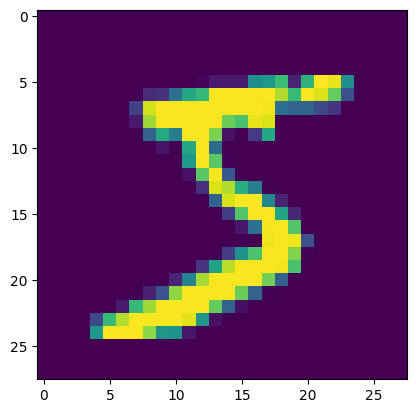

In [31]:
plt.imshow(X_train[0])

In [32]:
# flatten images into one-dimensional vector
num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector
num_pixels

784

In [33]:
X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

In [34]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

In [35]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [36]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


In [37]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [38]:
# define classification model
def classification_model():
    # create model

    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))


    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [39]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9428 - loss: 0.1879 - val_accuracy: 0.9738 - val_loss: 0.0855
Epoch 2/10
1875/1875 - 33s - 18ms/step - accuracy: 0.9747 - loss: 0.0800 - val_accuracy: 0.9776 - val_loss: 0.0728
Epoch 3/10
1875/1875 - 32s - 17ms/step - accuracy: 0.9829 - loss: 0.0543 - val_accuracy: 0.9755 - val_loss: 0.0830
Epoch 4/10
1875/1875 - 24s - 13ms/step - accuracy: 0.9868 - loss: 0.0401 - val_accuracy: 0.9806 - val_loss: 0.0674
Epoch 5/10
1875/1875 - 39s - 21ms/step - accuracy: 0.9898 - loss: 0.0309 - val_accuracy: 0.9769 - val_loss: 0.0916
Epoch 6/10
1875/1875 - 21s - 11ms/step - accuracy: 0.9919 - loss: 0.0253 - val_accuracy: 0.9788 - val_loss: 0.0843
Epoch 7/10
1875/1875 - 24s - 13ms/step - accuracy: 0.9923 - loss: 0.0240 - val_accuracy: 0.9802 - val_loss: 0.0737
Epoch 8/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9943 - loss: 0.0184 - val_accuracy: 0.9834 - val_loss: 0.0756
Epoch 9/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9944 - loss: 0.0168 - val_a

In [40]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))

Accuracy: 0.9825999736785889% 
 Error: 0.017400026321411133


In [41]:
model.save('classification_model.keras')

In [42]:
pretrained_model = keras.saving.load_model('classification_model.keras')

Create a neural network model with 6 dense layers and compare its accuracy

In [43]:
# define classification model
def classification_model_6layers():
    # create model

    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))


    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# build the model
model_6layers = classification_model_6layers()

# fit the model
model_6layers.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_6layers = model_6layers.evaluate(X_test, y_test, verbose=0)

print('Accuracy_3_layers: {}% \n Accuracy_6_layers: {}'.format(scores[1], scores_6layers[1]))


Epoch 1/10
1875/1875 - 26s - 14ms/step - accuracy: 0.9333 - loss: 0.2202 - val_accuracy: 0.9627 - val_loss: 0.1225
Epoch 2/10
1875/1875 - 22s - 12ms/step - accuracy: 0.9702 - loss: 0.1006 - val_accuracy: 0.9712 - val_loss: 0.0952
Epoch 3/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9785 - loss: 0.0724 - val_accuracy: 0.9762 - val_loss: 0.0797
Epoch 4/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9830 - loss: 0.0578 - val_accuracy: 0.9686 - val_loss: 0.1253
Epoch 5/10
1875/1875 - 41s - 22ms/step - accuracy: 0.9864 - loss: 0.0464 - val_accuracy: 0.9773 - val_loss: 0.0821
Epoch 6/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9882 - loss: 0.0396 - val_accuracy: 0.9797 - val_loss: 0.0763
Epoch 7/10
1875/1875 - 22s - 12ms/step - accuracy: 0.9901 - loss: 0.0345 - val_accuracy: 0.9798 - val_loss: 0.0893
Epoch 8/10
1875/1875 - 22s - 12ms/step - accuracy: 0.9914 - loss: 0.0293 - val_accuracy: 0.9799 - val_loss: 0.0875
Epoch 9/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9919 - loss: 0.0285 - val_a

Now, load the the earlier saved model, train it further for 10 more epochs and check the accuracy

In [44]:
pretrained_model = keras.saving.load_model('classification_model.keras')

print("Pre-trained model loaded successufully")

# fit the model
pretrained_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_20_epochs = pretrained_model.evaluate(X_test, y_test, verbose=0)

Pre-trained model loaded successufully
Epoch 1/10
1875/1875 - 24s - 13ms/step - accuracy: 0.9952 - loss: 0.0156 - val_accuracy: 0.9819 - val_loss: 0.0911
Epoch 2/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9964 - loss: 0.0124 - val_accuracy: 0.9804 - val_loss: 0.1105
Epoch 3/10
1875/1875 - 42s - 22ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9803 - val_loss: 0.1139
Epoch 4/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9965 - loss: 0.0120 - val_accuracy: 0.9792 - val_loss: 0.1267
Epoch 5/10
1875/1875 - 25s - 13ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9797 - val_loss: 0.1204
Epoch 6/10
1875/1875 - 21s - 11ms/step - accuracy: 0.9964 - loss: 0.0124 - val_accuracy: 0.9808 - val_loss: 0.1217
Epoch 7/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9976 - loss: 0.0087 - val_accuracy: 0.9850 - val_loss: 0.0861
Epoch 8/10
1875/1875 - 23s - 12ms/step - accuracy: 0.9964 - loss: 0.0126 - val_accuracy: 0.9838 - val_loss: 0.1019
Epoch 9/10
1875/1875 - 40s - 21ms/step - 

In [45]:
print('Accuracy_10_epochs: {}% \n Accuracy_20_epochs: {}'.format(scores[1], scores_20_epochs[1]))

Accuracy_10_epochs: 0.9825999736785889% 
 Accuracy_20_epochs: 0.9825000166893005
